In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports successful")

✅ All imports successful


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/multimodal_dementia_dataset.csv')

# Safety checks
assert df.shape == (225, 29), f"Unexpected shape: {df.shape}"
assert df.isnull().sum().sum() == 0, "NaNs found in dataset!"
assert df['Label'].isin([0, 1]).all(), "Invalid labels found!"

print(f"Dataset loaded: {df.shape}")
print(f"Label distribution:\n{df['Label'].value_counts()}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: (225, 29)
Label distribution:
Label
0    124
1    101
Name: count, dtype: int64
Columns: ['Subject_ID', 'CDR', 'MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV', 'hippocampal_volume', 'cortical_thickness', 'pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'Label']


In [4]:
MRI_FEATURES = ['nWBV', 'eTIV', 'hippocampal_volume', 'cortical_thickness']

print("=== MRI FEATURE OVERVIEW ===")
print(df[MRI_FEATURES].describe().round(3))
print(f"\nNull values: {df[MRI_FEATURES].isnull().sum().to_dict()}")

print("\n=== PER-CLASS MEANS ===")
print(df.groupby('Label')[MRI_FEATURES].mean().round(3))

=== MRI FEATURE OVERVIEW ===
          nWBV      eTIV  hippocampal_volume  cortical_thickness
count  225.000   225.000             225.000             225.000
mean     0.711  1537.996            3224.689               2.543
std      0.043   146.202             607.047               0.351
min      0.620  1151.000            1756.000               1.750
25%      0.674  1442.000            2671.000               2.244
50%      0.716  1532.000            3341.000               2.596
75%      0.746  1642.000            3749.000               2.845
max      0.807  1948.000            4225.000               3.326

Null values: {'nWBV': 0, 'eTIV': 0, 'hippocampal_volume': 0, 'cortical_thickness': 0}

=== PER-CLASS MEANS ===
        nWBV      eTIV  hippocampal_volume  cortical_thickness
Label                                                         
0      0.743  1557.823            3716.863               2.818
1      0.670  1513.653            2620.436               2.205


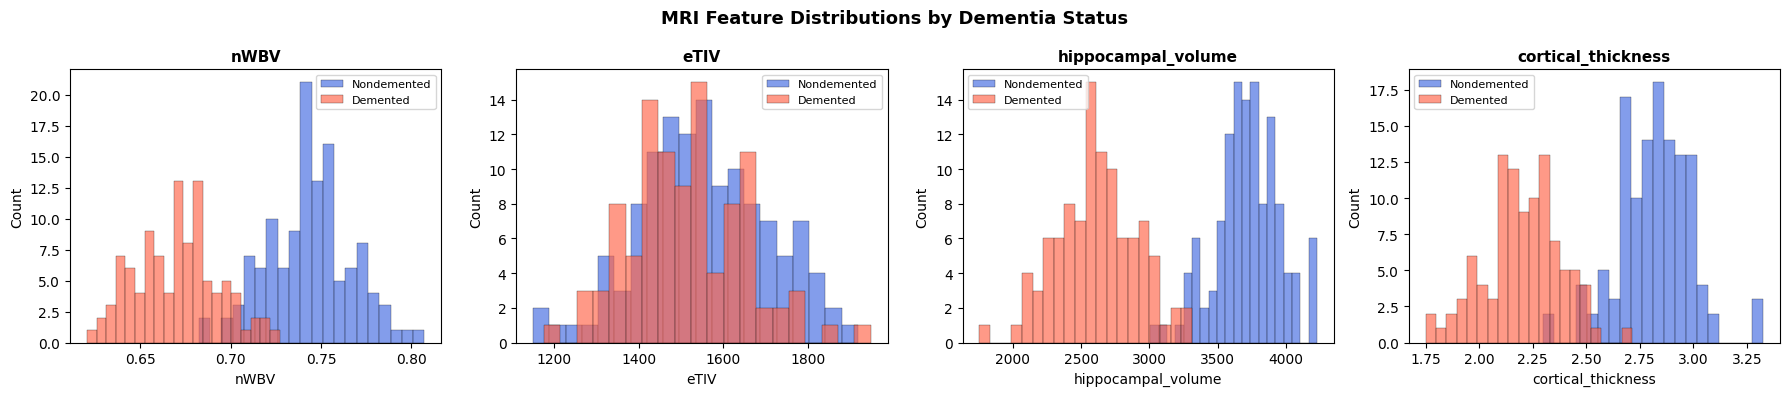

Saved: results/plots/mri_feature_distributions.png


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = {0: 'royalblue', 1: 'tomato'}
label_names = {0: 'Nondemented', 1: 'Demented'}

for ax, feat in zip(axes, MRI_FEATURES):
    for lbl in [0, 1]:
        ax.hist(df[df['Label']==lbl][feat],
                bins=20, alpha=0.65, color=colors[lbl],
                label=label_names[lbl], edgecolor='black', linewidth=0.3)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('MRI Feature Distributions by Dementia Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/mri_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/plots/mri_feature_distributions.png")

In [6]:
X_mri = df[MRI_FEATURES].values
y = df['Label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mri)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  after scaling (should be ~1): {X_scaled.std(axis=0).round(4)}")

Feature matrix shape: (225, 4)
Mean after scaling (should be ~0): [-0.  0.  0. -0.]
Std  after scaling (should be ~1): [1. 1. 1. 1.]


Explained variance per component: [0.6448 0.2398]
Total variance retained: 88.45%
Shape after PCA: (225, 2)


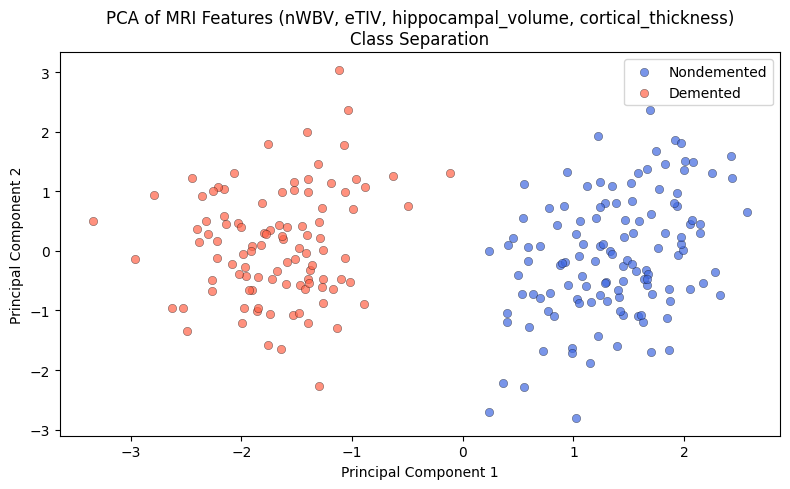

Saved: results/plots/mri_pca.png


In [7]:
# Reduce 4 MRI features → 2 principal components
# With 4 input features, PCA(2) captures the most important variance directions
# (brain volume + thickness tend to be correlated, so PC1 captures overall atrophy)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance per component: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Shape after PCA: {X_pca.shape}")   # should be (225, 2)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1],
            c='royalblue', label='Nondemented', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1],
            c='tomato', label='Demented', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MRI Features (nWBV, eTIV, hippocampal_volume, cortical_thickness)\nClass Separation')
plt.legend()
plt.tight_layout()
plt.savefig('results/plots/mri_pca.png', dpi=150)
plt.show()
print("Saved: results/plots/mri_pca.png")

In [8]:
np.save('results/X_mri_pca.npy', X_pca)

print(f"✅ Saved: results/X_mri_pca.npy  — shape: {X_pca.shape}")

check = np.load('results/X_mri_pca.npy')
assert check.shape == (225, 2), f"Wrong shape: {check.shape}"
print("✅ Reload check passed")

✅ Saved: results/X_mri_pca.npy  — shape: (225, 2)
✅ Reload check passed
